## 1  ·  Configure Groq LLM

Set your Groq API key and choose a model. Groq provides fast inference for SQL tasks.

In [27]:
# ─────────────────────────────────────────────────────────────
# Use Groq API 
# ─────────────────────────────────────────────────────────────
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")


model = ChatGroq(
    model="openai/gpt-oss-120b",  # or try "gemma-7b-it", "openai/gpt-oss-120b"
    temperature=0,               # deterministic SQL generation
    api_key=GROQ_API_KEY,
)

print(f"✓ Groq model loaded: openai/gpt-oss-120b")

✓ Groq model loaded: openai/gpt-oss-120b


## 2  ·  Connect to the PostgreSQL Database

Setup the database connection that the agent will use to inspect schema and execute queries.

In [28]:
from langchain_community.utilities import SQLDatabase

# ── Connection settings (from test.ipynb) ─────────────────────
DB_USER     = "admin"
DB_PASSWORD = "admin%40123"          # URL-encoded: @ → %40
DB_HOST     = "100.90.162.48"
DB_PORT     = "5432"
DB_NAME     = "chicago_crime"

# Build a standard SQLAlchemy URI
DB_URI = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Wrap it with LangChain's SQLDatabase so the agent can use it
# include_tables=None means all tables are accessible;
# pass a list like ['chicago_crime'] to restrict access.
db = SQLDatabase.from_uri(DB_URI)

print(f"Dialect         : {db.dialect}")
print(f"Available tables: {db.get_usable_table_names()}")

Dialect         : postgresql
Available tables: ['chicago_crime']


## 3  ·  Build and Run the Agent

The `build_groq_agent()` function from `sql_agent.py` handles all the LangGraph setup, tools, and graph building. Simply call it with your database URI.

In [24]:
# Import the agent builder and runner from sql_agent module
from sql_agent import build_groq_agent, run_agent

# Build the Groq-powered agent
agent = build_groq_agent(db_uri=DB_URI)

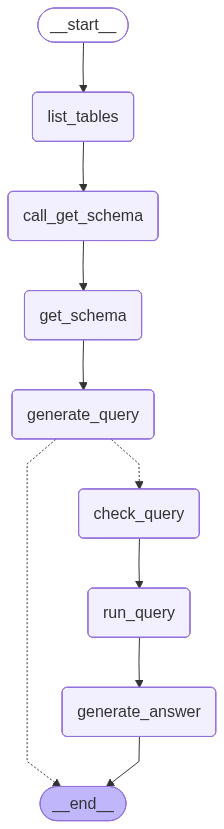

In [25]:
agent

In [26]:
# Example queries
run_agent(agent, "what is total crimes in 2025?")


Question: what is total crimes in 2025?
================================ Human Message =================================

what is total crimes in 2025?
================================== Ai Message ==================================

Available tables: chicago_crime
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (fc_b9816cfb-f71e-438c-984b-7c695c11c207)
 Call ID: fc_b9816cfb-f71e-438c-984b-7c695c11c207
  Args:
    table_names: chicago_crime
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE chicago_crime (
	"ID" BIGINT, 
	case_number TEXT, 
	"Date" TEXT, 
	"Block" TEXT, 
	"IUCR" TEXT, 
	crime_type TEXT, 
	"Description" TEXT, 
	location_description TEXT, 
	"Arrest" BOOLEAN, 
	"Domestic" BOOLEAN, 
	"Beat" BIGINT, 
	"District" BIGINT, 
	"Ward" DOUBLE PRECISION, 
	community_area DOUBLE PRECISION, 
	fbi_code TEXT, 
	x_coordinate DOUBLE PRECISION, 
	y_coordinate DOUB